In [94]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import imageio

from torch.utils.data import DataLoader, TensorDataset

In [95]:
import sys
import os
sys.path.append(os.path.abspath("../"))

from src.lyap import NN_LyapExp
from src.networks import NeuralODEClassifier, NeuralODE_Truncated, init_weights

In [96]:
from matplotlib.colors import LinearSegmentedColormap

tf_playground = LinearSegmentedColormap.from_list(
    "tf_playground",
    [
        "#f4a261", # orange
        "#ffffff", # white
        "#2a9df4"  # blue
    ]
)

In [97]:
def circle_dataset(N_samples, epsilon, seed=None):
    if seed is not None:
        np.random.seed(seed)

    assert N_samples % 2 == 0, "N_samples should be even for a balanced dataset"
    n_half = N_samples // 2

    # Sample inside the circle
    X_inside = []
    while len(X_inside) < n_half:
        x = np.random.uniform(-1, 1, size=(n_half * 2, 2))  # oversample a bit
        mask = np.sum(x**2, axis=1) <= 1 - epsilon
        X_inside.extend(x[mask])
    X_inside = np.array(X_inside[:n_half])

    # Sample outside the circle
    X_outside = []
    while len(X_outside) < n_half:
        x = np.random.uniform(-2, 2, size=(n_half * 2, 2))
        mask = np.sum(x**2, axis=1) > 1 + epsilon
        X_outside.extend(x[mask])
    X_outside = np.array(X_outside[:n_half])

    # Combine
    X = np.vstack([X_inside, X_outside])
    y_signed = np.array([-1]*n_half + [1]*n_half)

    return X, y_signed

In [98]:
generate = False

In [99]:
if generate:
    N_samples = 500

    X_train, y_train = circle_dataset(N_samples, epsilon=0.1)

    np.savez(
        "circle_dataset_eps0p01.npz",
        X=X_train,
        y=y_train,
        epsilon=0.1
    )

else:
    data = np.load("circle_dataset_eps0p01.npz")
    X_train = data["X"]
    y_train = data["y"]

    epsilon = data["epsilon"]

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train_standardized = (X_train - mean)/std

In [100]:
N_samples_test = 4000
X_test, y_test = circle_dataset(N_samples_test, epsilon=0)

X_test_standardized = (X_test - mean)/std

In [101]:
X_train_standardized = torch.tensor(X_train_standardized, dtype=torch.float32).float()
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).float()  # add dimension if needed

X_test_standardized = torch.tensor(X_test_standardized, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [102]:
neural_ode = NeuralODEClassifier(input_dim=2, hidden_dim=3)
neural_ode.apply(lambda m: init_weights(m, init_type="orthogonal", gain=0.9))

train_ds = TensorDataset(X_train_standardized, y_train)
test_ds = TensorDataset(X_test_standardized, y_test)

train_dataloader = DataLoader(train_ds, batch_size=4096, shuffle=True)
test_dataloader = DataLoader(test_ds, batch_size=64)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(neural_ode.parameters(), lr=1e-3) 

In [103]:
x_vals = np.linspace(-2, 2, 100)
y_vals = np.linspace(-2, 2, 100)

In [104]:
lyap_grid = np.zeros((len(x_vals), len(y_vals)))

neural_ode_trunc = NeuralODE_Truncated(neural_ode_model=neural_ode)

nn_lyap = NN_LyapExp(neural_ode_trunc)

for i, x in enumerate(x_vals):
    for j, y in enumerate(y_vals):

        # Create 1×2 input
        x0 = torch.tensor([[x, y]], dtype=torch.float32)

        # Standardize using your saved statistics
        x0 = ((x0 - mean) / std).float()

        # Compute Jacobian
        J = nn_lyap.jacobian(x0)

        # Singular values
        svals = torch.linalg.svdvals(J)

        # Largest Lyapunov proxy
        lyap_grid[j, i] = torch.log(svals.max()).item()

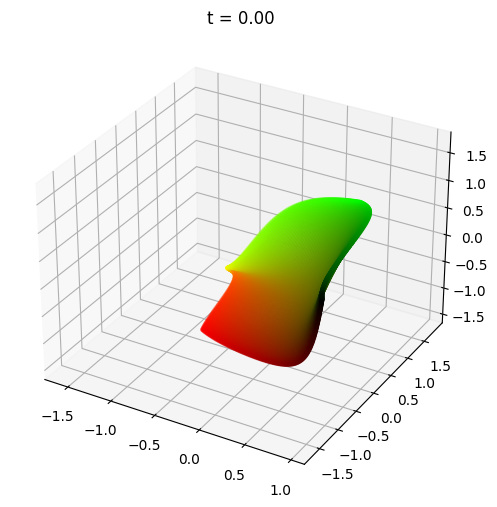

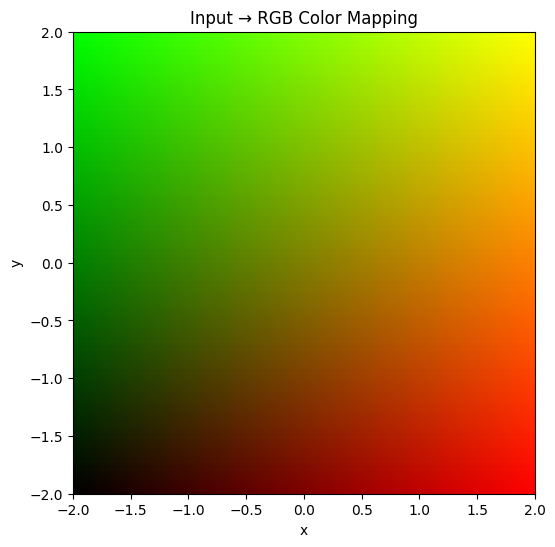

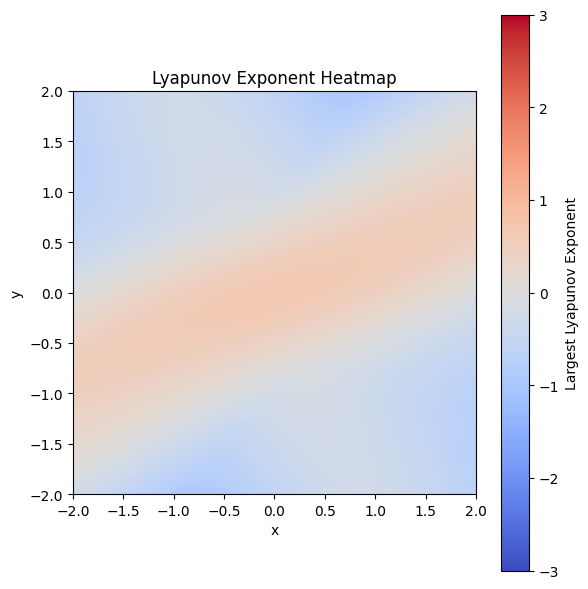

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(
    lyap_grid,
    extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
    origin='lower',
    cmap='coolwarm',        # or 'viridis', 'plasma', etc.
    vmin=-3,
    vmax=3
)
plt.colorbar(label="Largest Lyapunov Exponent")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Lyapunov Exponent Heatmap")
plt.tight_layout()
plt.show()

In [106]:
loss_history = []
loss_window = 50  # Number of epochs over which we want to average the loss
loss_tol = 5e-4  # Tolerance under which we stop

In [107]:
def avg_jacobian_norm(model, X):
    X = X.float().requires_grad_(True)

    z0 = torch.tanh(model.input_layer(X))
    f = model.odefunc(0, z0)               # Vector field evaluation
    jac_list = []

    for i in range(f.shape[0]):
        grad_f = torch.autograd.grad(f[i].sum(), z0, retain_graph=True, create_graph=False)[0]
        jac_list.append(grad_f[i].norm().item())

    return sum(jac_list)/len(jac_list)

In [108]:
jac_history = []
jac_tol = 0.01   # Threshold for stabilization
jac_window = 20  # moving average window for Jacobian norm

In [ ]:
patience = 50
trigger_times = 0

for epoch in range(2500):
    epoch_loss = 0.0
    for x_batch, y_batch in train_dataloader:
        x_batch = x_batch.float()
        y_batch = y_batch.float()
        
        # Forward pass
        pred = neural_ode(x_batch)
        loss = loss_fn(pred, y_batch.squeeze())

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * x_batch.size(0)

    # Average loss over all of the dataset
    epoch_loss /= len(train_dataloader.dataset)
    loss_history.append(epoch_loss)

    # Compute average jacobian loss on a subset (for speed)
    jac_norm = avg_jacobian_norm(neural_ode, x_batch[:64]) # take 64 samples
    jac_history.append(jac_norm)

    # Print the progress
    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Loss {epoch_loss:.6f} | Avg Jac Norm {jac_norm:.6f}")

    if len(loss_history) >= loss_window:
        recent_slope = sum(abs(loss_history[-loss_window+1:] - np.array(loss_history[-loss_window:-1]))) / (loss_window-1)

    else:
        recent_slope = float("inf")

    # Check Jacobian stabilization
    if len(jac_history) >= jac_window:
        recent_jac_change = sum(abs(jac_history[-jac_window+1:] - np.array(jac_history[-jac_window:-1]))) / (jac_window-1)
    
    else:
        recent_jac_change = float('inf')

    # Early stopping
    if recent_slope < loss_tol and recent_jac_change < jac_tol:
        trigger_times += 1
        if trigger_times > patience:
            print(f"Early stopping at epoch {epoch}")
            break
    else:
        trigger_times = 0

Epoch 0 | Loss 1.475456 | Avg Jac Norm 1.335223
Epoch 20 | Loss 1.410177 | Avg Jac Norm 1.317864
Epoch 40 | Loss 1.342537 | Avg Jac Norm 1.292959
Epoch 60 | Loss 1.272121 | Avg Jac Norm 1.321467
Epoch 80 | Loss 1.201183 | Avg Jac Norm 1.343243
Epoch 100 | Loss 1.136547 | Avg Jac Norm 1.332135
Epoch 120 | Loss 1.077747 | Avg Jac Norm 1.325600
Epoch 140 | Loss 1.024863 | Avg Jac Norm 1.328186
Epoch 160 | Loss 0.981520 | Avg Jac Norm 1.328386
Epoch 180 | Loss 0.947045 | Avg Jac Norm 1.313309
Epoch 200 | Loss 0.919542 | Avg Jac Norm 1.290772
Epoch 220 | Loss 0.897408 | Avg Jac Norm 1.265692
Epoch 240 | Loss 0.879127 | Avg Jac Norm 1.247567
Epoch 260 | Loss 0.863175 | Avg Jac Norm 1.252219
Epoch 280 | Loss 0.848341 | Avg Jac Norm 1.261439
Epoch 300 | Loss 0.833874 | Avg Jac Norm 1.242172
Epoch 320 | Loss 0.819377 | Avg Jac Norm 1.259235
Epoch 340 | Loss 0.804638 | Avg Jac Norm 1.239822
Epoch 360 | Loss 0.789506 | Avg Jac Norm 1.247153
Epoch 380 | Loss 0.773821 | Avg Jac Norm 1.248992
Epoch 

In [110]:
lyap_grid = np.zeros((len(x_vals), len(y_vals)))

neural_ode_trunc = NeuralODE_Truncated(neural_ode_model=neural_ode)

nn_lyap = NN_LyapExp(neural_ode_trunc)

for i, x in enumerate(x_vals):
    for j, y in enumerate(y_vals):

        # Create 1×2 input
        x0 = torch.tensor([[x, y]], dtype=torch.float32)

        # Standardize using your saved statistics
        x0 = ((x0 - mean) / std).float()

        # Compute Jacobian
        J = nn_lyap.jacobian(x0)

        # Singular values
        svals = torch.linalg.svdvals(J)

        # Largest Lyapunov proxy
        lyap_grid[j, i] = torch.log(svals.max()).item()

In [111]:
X, Y = np.meshgrid(x_vals, y_vals)

points = np.stack([X.ravel(), Y.ravel()], axis=1)
points_t = torch.tensor(points, dtype=torch.float32)

points_t = ((points_t - mean) / std).float()

In [112]:
neural_ode.eval()
with torch.no_grad():
    preds = neural_ode(points_t).cpu().numpy()

Z = preds.reshape(len(x_vals), len(y_vals))

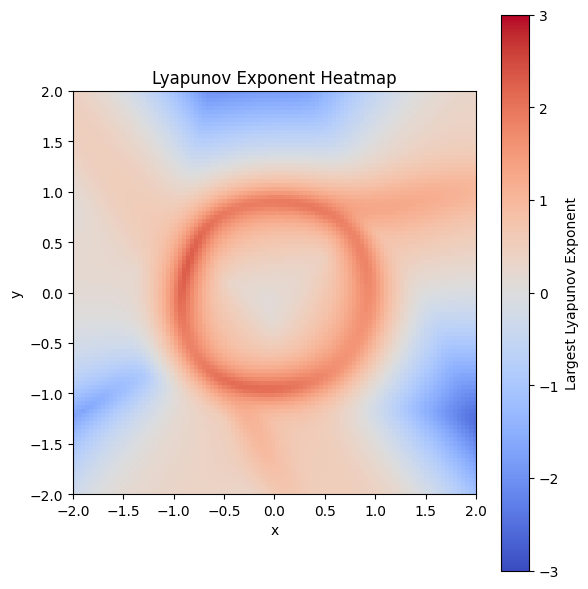

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(
    lyap_grid,
    extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
    origin='lower',
    cmap='coolwarm',        # or 'viridis', 'plasma', etc.
    vmin=-3,
    vmax=3
)
plt.colorbar(label="Largest Lyapunov Exponent")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Lyapunov Exponent Heatmap")
plt.tight_layout()
plt.show()

In [114]:
nn_lyap_full = NN_LyapExp(neural_ode)

lyap_grid_full = np.zeros((len(x_vals), len(y_vals)))

for i, x in enumerate(x_vals):
    for j, y in enumerate(y_vals):

        # Create 1×2 input
        x0 = torch.tensor([[x, y]], dtype=torch.float32)

        # Standardize using your saved statistics
        x0 = ((x0 - mean) / std).float()

        # Compute Jacobian
        J = nn_lyap_full.jacobian(x0)

        # Singular values
        svals = torch.linalg.svdvals(J)

        # Largest Lyapunov proxy
        lyap_grid_full[j, i] = torch.log(svals.max()).item()

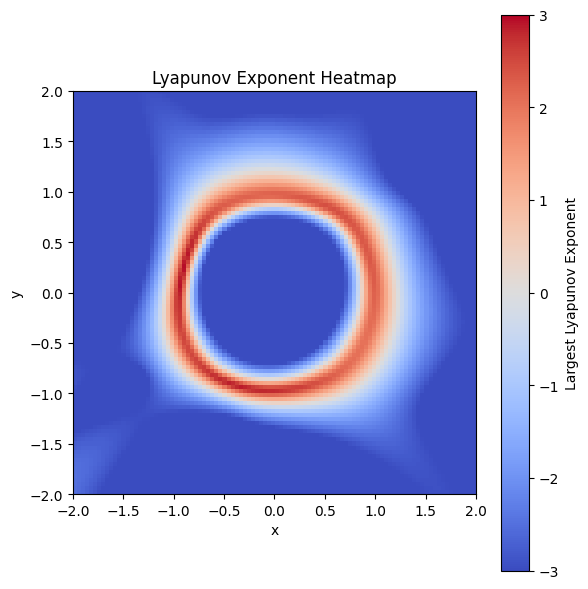

In [115]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(
    lyap_grid_full,
    extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
    origin='lower',
    cmap='coolwarm',        # or 'viridis', 'plasma', etc.
    vmin=-3,
    vmax=3
)
plt.colorbar(label="Largest Lyapunov Exponent")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Lyapunov Exponent Heatmap")
plt.tight_layout()
plt.show()

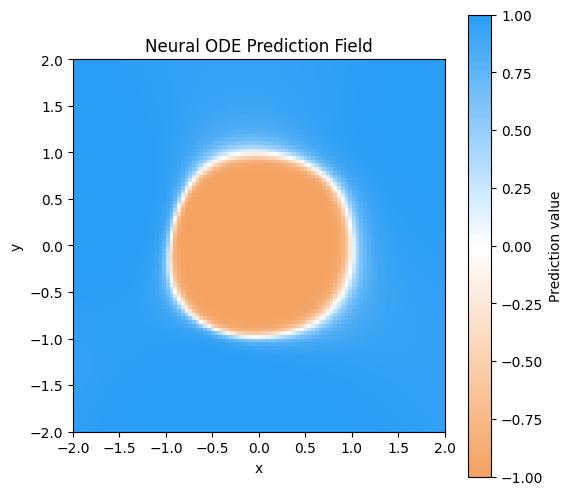

In [116]:
plt.figure(figsize=(6,6))
plt.imshow(
    Z,
    extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
    origin='lower',
    cmap=tf_playground,
    vmin=-1,
    vmax=1
)
plt.colorbar(label="Prediction value")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Neural ODE Prediction Field")
plt.show()


In [117]:
t_eval = torch.linspace(0, 1, 60)

with torch.no_grad():
    traj = neural_ode.get_hidden_trajectory(points_t, t_eval) # Shape time_steps, num_points, 3

In [118]:
x_colors = points_t[:, 0]
y_colors = points_t[:, 1]

labels = torch.where(x_colors**2 + y_colors**2 <= 1.0, -1, 1)

colors = torch.zeros((points_t.shape[0], 3)) # RGB

# Red if the point is inside the circle
colors[labels == -1] = torch.tensor([1.0, 0.0, 0.0])

# Blue if the point is outside the circle
colors[labels == 1] = torch.tensor([0.0, 0.0, 1.0])
colors_np = colors.numpy()

In [119]:
x_norm = (x_colors - x_colors.min()) / (x_colors.max() - x_colors.min())
y_norm = (y_colors - y_colors.min()) / (y_colors.max() - y_colors.min())

colors_input = torch.stack([x_norm, y_norm, torch.zeros_like(x_norm)], dim=1).numpy()

In [120]:
from matplotlib.animation import FuncAnimation
import matplotlib
matplotlib.use("Agg")

T, N, _ = traj.shape
traj_np = traj.cpu().numpy()

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# Initial scatter
scatter = ax.scatter(traj_np[0,:,0], traj_np[0,:,1], traj_np[0,:,2], c=colors_input, s=5)

ax.set_xlim(traj_np[:,:,0].min(), traj_np[:,:,0].max())
ax.set_ylim(traj_np[:,:,1].min(), traj_np[:,:,1].max())
ax.set_zlim(traj_np[:,:,2].min(), traj_np[:,:,2].max())
ax.set_title("Neural ODE flow in hidden space")

def update(frame):
    scatter._offsets3d = (
        traj_np[frame,:,0],
        traj_np[frame,:,1],
        traj_np[frame,:,2],
    )
    ax.set_title(f"t = {frame/(T-1):.2f}")
    return scatter,

anim = FuncAnimation(fig, update, frames=T, interval=80)

# anim.save("ode_tanh_hidden_flow_input_colors.gif", writer="pillow", fps=15)
# print("Saved GIF: ode_tanh_hidden_flow_input_colors.gif")

In [121]:
colors_grid = colors_input.reshape(len(x_vals), len(y_vals), 3)
plt.figure(figsize=(6,6))
plt.imshow(colors_grid, origin='lower',
           extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()])
plt.xlabel("x")
plt.ylabel("y")
plt.title("Input → RGB Color Mapping")
plt.show()

C:\Users\m.tonti\AppData\Local\Temp\ipykernel_16508\2842135522.py:8: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


In [122]:
%matplotlib inline